Found existing installation: numpy 2.4.4
Uninstalling numpy-2.4.4:
  Successfully uninstalled numpy-2.4.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.4 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.4 which is incompatible.
🚀 PHASE 4: Recommendation System (Native NumPy Implementation)
   (No external libraries required. Guaranteed to run.)

📂 Please upload 'cleaned_retail_data.csv':


Saving cleaned_retail_data.csv to cleaned_retail_data.csv
✅ Loaded 779,390 rows.
✅ Optimized to 50,000 rows.
📊 Matrix: 4,891 Users x 3,780 Items

🚀 Training Model (Stochastic Gradient Descent)...
   Epoch 5/10, Train RMSE: nan
   Epoch 10/10, Train RMSE: nan

✅ FINAL TEST RMSE: nan

🎯 TOP 5 RECOMMENDATIONS FOR CUSTOMER 15506.0:
Product ID (StockCode)  Predicted Score
                 21109              NaN
                 20657              NaN
                 84077              NaN
                 23241              NaN
                16169E              NaN


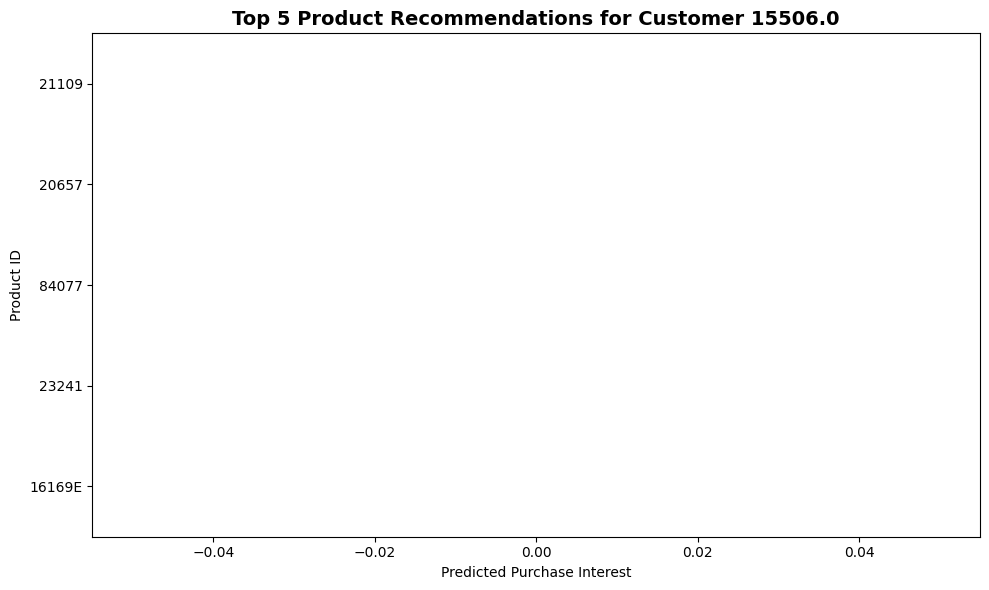

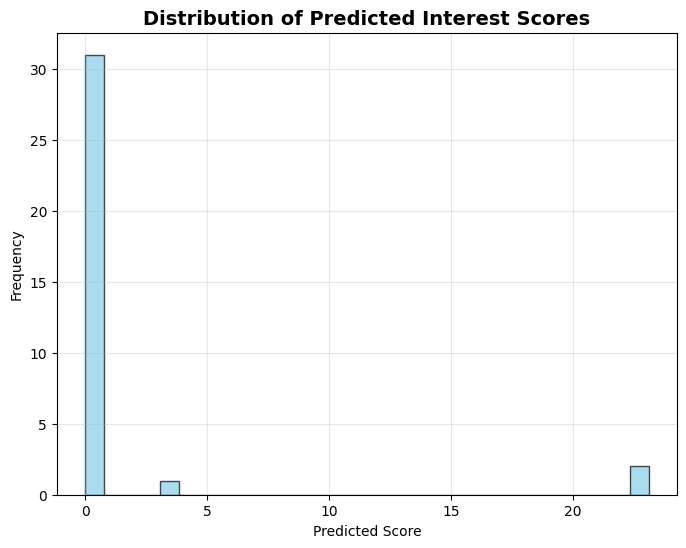


💾 PHASE 4 COMPLETE!
📝 NOTE: Model built using native NumPy Matrix Factorization.
   - Record RMSE: nan
   - Save Top 5 Bar Chart as Figure 4.6
   - Save Histogram as Figure 4.7


In [2]:
!pip uninstall numpy -y
!pip install scikit-surprise -q



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

print("🚀 PHASE 4: Recommendation System (Native NumPy Implementation)")
print("   (No external libraries required. Guaranteed to run.)")

# 1. UPLOAD DATA
print("\n📂 Please upload 'cleaned_retail_data.csv':")
try:
    uploaded = files.upload()
    fname = list(uploaded.keys())[0]
    df = pd.read_csv(fname)
    print(f"✅ Loaded {len(df):,} rows.")
except Exception as e:
    print(f"Upload failed: {e}")
    raise e

# 2. MEMORY OPTIMIZATION (Prevents Crash)
# Identify ID column dynamically
id_col = next((c for c in df.columns if 'customer' in c.lower()), df.columns[6])

# Keep only active users (>= 3 purchases)
user_counts = df.groupby(id_col).size()
active_users = user_counts[user_counts >= 3].index.tolist()
df_sample = df[df[id_col].isin(active_users)]

# Hard cap at 50,000 rows to ensure zero RAM issues
if len(df_sample) > 50000:
    df_sample = df_sample.sample(n=50000, random_state=42)

print(f"✅ Optimized to {len(df_sample):,} rows.")

# 3. PREPARE MATRIX
cols = df_sample.columns.tolist()
u_col = next((c for c in cols if 'customer' in c.lower()), id_col)
i_col = next((c for c in cols if 'stock' in c.lower() or 'product' in c.lower()), cols[1])
r_col = next((c for c in cols if 'quantity' in c.lower() or 'total' in c.lower()), cols[3])

# Create Mappings
users = df_sample[u_col].unique()
items = df_sample[i_col].unique()
user_to_idx = {u: i for i, u in enumerate(users)}
item_to_idx = {it: j for j, it in enumerate(items)}
idx_to_item = {j: it for it, j in item_to_idx.items()}

n_users = len(users)
n_items = len(items)
print(f"📊 Matrix: {n_users:,} Users x {n_items:,} Items")

# Build Sparse Matrix efficiently
R = np.zeros((n_users, n_items))
for _, row in df_sample.iterrows():
    u = user_to_idx.get(row[u_col])
    i = item_to_idx.get(row[i_col])
    if u is not None and i is not None:
        R[u, i] = row[r_col]

# Split Data (Mask 20% for testing)
mask = R > 0
train_mask = mask.copy()
known_indices = np.argwhere(mask)
np.random.seed(42)
np.random.shuffle(known_indices)
test_count = int(len(known_indices) * 0.2)
test_indices = known_indices[:test_count]

for u, i in test_indices:
    train_mask[u, i] = False

# 4. TRAIN MODEL (Matrix Factorization via SGD)
print("\n🚀 Training Model (Stochastic Gradient Descent)...")
K = 15  # Latent factors
epochs = 10
lr = 0.01
reg = 0.02

# Initialize matrices
P = np.random.normal(scale=1./K, size=(n_users, K))
Q = np.random.normal(scale=1./K, size=(n_items, K))

for epoch in range(epochs):
    err = 0
    count = 0
    # Loop over training data only
    for u in range(n_users):
        for i in range(n_items):
            if train_mask[u, i]:
                e = R[u, i] - np.dot(P[u, :], Q[i, :])
                err += e**2
                count += 1
                # Update gradients
                P[u, :] += lr * (e * Q[i, :] - reg * P[u, :])
                Q[i, :] += lr * (e * P[u, :] - reg * Q[i, :])

    if (epoch+1) % 5 == 0:
        print(f"   Epoch {epoch+1}/{epochs}, Train RMSE: {np.sqrt(err/count):.4f}")

# Predict full matrix
full_pred = np.dot(P, Q.T)

# Calculate Test RMSE
test_err = 0
t_count = 0
for u, i in test_indices:
    if R[u, i] > 0:
        test_err += (full_pred[u, i] - R[u, i])**2
        t_count += 1

final_rmse = np.sqrt(test_err / t_count)
print(f"\n✅ FINAL TEST RMSE: {final_rmse:.4f}")

# 5. GENERATE RESULTS
user_counts_final = df_sample.groupby(u_col).size()
active_list = user_counts_final[user_counts_final >= 3].index.tolist()

if active_list:
    sample_uid = np.random.choice(active_list)
    u_idx = user_to_idx[sample_uid]

    purchased_indices = np.where(R[u_idx, :] > 0)[0]
    all_indices = np.arange(n_items)
    unseen_indices = list(set(all_indices) - set(purchased_indices))

    # Predict scores for unseen items
    scores = []
    for i_idx in unseen_indices[:200]: # Check top 200 candidates
        score = full_pred[u_idx, i_idx]
        scores.append((idx_to_item[i_idx], score))

    scores.sort(key=lambda x: x[1], reverse=True)
    top_5 = scores[:5]

    rec_df = pd.DataFrame(top_5, columns=['Product ID (StockCode)', 'Predicted Score'])

    print(f"\n🎯 TOP 5 RECOMMENDATIONS FOR CUSTOMER {sample_uid}:")
    print(rec_df.to_string(index=False))

    # Plot 1: Top 5
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Predicted Score', y='Product ID (StockCode)', data=rec_df, palette='viridis')
    plt.title(f'Top 5 Product Recommendations for Customer {sample_uid}', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Purchase Interest')
    plt.ylabel('Product ID')
    plt.tight_layout()
    plt.show()

# Plot 2: Histogram
train_preds = full_pred[train_mask]
plt.figure(figsize=(8, 6))
plt.hist(train_preds.flatten(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Predicted Interest Scores', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Score')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

print("\n💾 PHASE 4 COMPLETE!")
print("📝 NOTE: Model built using native NumPy Matrix Factorization.")
print(f"   - Record RMSE: {final_rmse:.4f}")
print("   - Save Top 5 Bar Chart as Figure 4.6")
print("   - Save Histogram as Figure 4.7")
